In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

import sys
import os
from pathlib import Path

# move upward until we find repo root
repo_root = Path.cwd()

while not (repo_root / ".git").exists():
    repo_root = repo_root.parent

sys.path.append(str(repo_root))
from config import config
from DataPipeline.utils.bets_utils import generate_bets 

In [59]:
non_merged = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\non_merged_features\non_merged_stats.csv')
df_ml_history = pd.read_csv(config.ml_history_fp)
df_parlay = pd.read_csv(config.parlay_history_fp)


In [60]:
df_kelly_stack2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_stacking.csv')
df_kelly_stack1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_stacking1.csv')

In [61]:
df_kelly_stack1.columns

Index(['Unnamed: 0', 'choice_decimal_odds', 'f_star_unscaled', 'choice_proba',
       'choice_fair_odds', 'choice_ev', 'choice_real_odds', 'choice_idx',
       'pred_winner', 'parlay_net', 'parlay_net_odds', 'parlay_ev',
       'bankroll_pct_change', 'bankroll_postevent', 'vegas_acc_choice',
       'event_payout_money_line', 'fight_payout', 'net_odds', 'choice_fstar',
       'event_ml_net_odds', 'kelly_edge', 'choice_bet_sharpe',
       'choice_bet_sigma', 'choice_edge', 'avg_choice_edge', 'date',
       'fighter_red', 'fighter_blue', 'winner', 'red_proba', 'blue_proba',
       'open_red', 'open_blue', 'real_odds_blue', 'real_odds_red',
       'sigma_portfolio_scaled', 'portfolio_fscaled', 'portfolio_sigma',
       'mu_portfolio', 'sharpe_portfolio', 'k', 'fstar_net', 'juice_open_red',
       'juice_open_blue', 'juice_close1_red', 'juice_close1_blue',
       'juice_close2_red', 'juice_close2_blue', 'close1_red', 'close1_blue',
       'close2_red', 'close2_blue'],
      dtype='str')

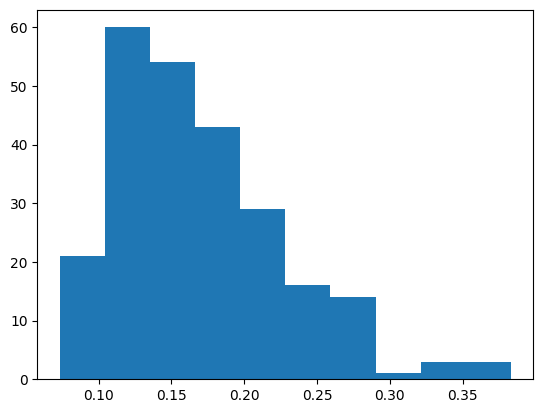

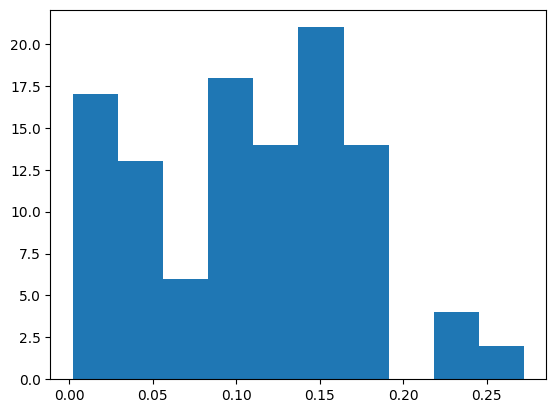

In [63]:
def compare_fstar(df1, df2, odds_type):

    fstar1 = df1['choice_fstar']
    fstar2 = df2[f'fstar_{odds_type}']

    plt.hist(fstar1[fstar1!=0])
    plt.show()

    plt.hist(fstar2[fstar2!=0])
    plt.show()

compare_fstar(df_kelly_stack1, df_ml_history, 'close1')

    

In [3]:
df_ml_history.shape

(275, 23)

In [3]:
from collections import defaultdict
def american_to_decimal(odds):
    odds = np.asarray(odds)
    return np.where(
        odds > 0, 
        1 + odds / 100, 
        1 + 100 / abs(odds)
    )

def returns_by_date(starting_bankroll=500):
    
    df_ml = pd.read_csv(config.ml_history_fp)
    df_parlay = pd.read_csv(config.parlay_history_fp)

    types = ['open', 'close1', 'close2']

    df_ml = pd.read_csv(config.ml_history_fp)
    df_parlay = pd.read_csv(config.parlay_history_fp)

    bankroll_data = defaultdict(list)
    parlay_data = defaultdict(list)
    ml_data = defaultdict(list)
    
    ml_data['date'] = df_ml['date']
    bankroll_data['date'] = df_parlay.groupby('date')['date'].first()
    parlay_data['date'] = df_parlay.groupby('date')['date'].first()

    for type_ in types: 

        date_index = df_ml['date']

        win_bet = pd.Series(0, index=date_index, dtype='boolean')
        mask_bet = df_ml[f"pred_winner_{type_}"].notna().to_numpy()

        win_bet.iloc[mask_bet] = (
            df_ml.loc[mask_bet, f"pred_winner_{type_}"].astype(int).to_numpy()
            == df_ml.loc[mask_bet, "winner_bool"].astype(int).to_numpy()
        )
        win_bet[~mask_bet] = False

        choice_stake = pd.Series(
            np.array(
                df_ml[f'fstar_{type_}'].fillna(0)
            ), 
        index=date_index
        )
        net_stake = choice_stake.where(win_bet, -choice_stake)
        net_stake = net_stake.where(mask_bet, 0)

        choice_odds = pd.Series(
            np.where(
                df_ml[f'pred_winner_{type_}'] == 1, 
                american_to_decimal(df_ml[f'{type_}_red'])-1, 
                american_to_decimal(df_ml[f'{type_}_blue'])-1
            ),
        index=date_index
        )
        choice_odds = choice_odds.fillna(0)
        net_odds = choice_odds.where(win_bet, -1)
        net_odds = net_odds.where(mask_bet, 0)

        ml_data[f'net_stake_{type_}'] = net_stake.copy()
        ml_data[f'net_odds_{type_}'] = net_odds.copy()


        date_index = df_parlay['date']

        leg_win = pd.Series(
            (df_parlay[f'choice_fighter_bool_{type_}'] == df_parlay[f'winner_bool_{type_}']).to_numpy(), 
            index=date_index
        )
        win_parlay = leg_win.groupby(level=0).all()
        single_date_index = win_parlay.index

        choice_parlay_odds = pd.Series(
            np.where(
                df_parlay[f'choice_fighter_bool_{type_}'] == 1,
                american_to_decimal(df_parlay[f'{type_}_red']),
                american_to_decimal(df_parlay[f'{type_}_blue'])
            ), 
            index=date_index
        ).fillna(0)

        parlay_stake = pd.Series(
            df_parlay.groupby('date')[f'{type_}_fstar'].first().fillna(0),
            index=single_date_index
        )
        parlay_net_stake = parlay_stake.where(win_parlay, -parlay_stake)

        parlay_odds = pd.Series(np.array(choice_parlay_odds.groupby(level=0).prod() - 1), index=single_date_index)
        parlay_net_odds = parlay_odds.where(win_parlay, -parlay_odds)

        parlay_data[f'net_odds_{type_}'] = parlay_net_odds.copy()
        parlay_data[f'net_stake_{type_}'] = parlay_net_stake.copy()
        parlay_data[f'win_parlay_{type_}'] = win_parlay.copy()

        bankroll = starting_bankroll
        bankroll_history = []
        profits = []
        for date in date_index.unique():

            wins = win_bet[mask_bet].loc[date]
            stakes = choice_stake[mask_bet].loc[date]
            odds = choice_odds[mask_bet].loc[date]

            profit_ml = np.where(
                wins, 
                stakes * bankroll * odds, 
                -stakes * bankroll
            )

            wins_parlay = win_parlay.loc[date]
            stakes_parlay = parlay_stake.loc[date]
            odds_parlay = parlay_odds.loc[date]

            profit_parlay = stakes_parlay * odds_parlay * bankroll if wins_parlay else -stakes_parlay * bankroll 

            total_profit = profit_ml.sum() + profit_parlay
            profits.append(total_profit) 

            bankroll += total_profit.sum()
            bankroll_history.append(bankroll)

        bankroll_data[f'bankroll_{type_}'] = bankroll_history
        bankroll_data[f'profits_{type_}'] = profits

    other_info = df_ml[[
        'open_red', 'open_blue', 'close1_red', 'close1_blue', 'close2_red', 'close2_blue',
        'fighter_red', 'fighter_blue', 'pred_winner_open', 'pred_winner_close1', 'pred_winner_close2',
        'winner_bool', 'winner_name'
    ]].reset_index(drop=True)

    ml_results = {
        key: value.to_numpy()
        for key, value in dict(ml_data).items()
    }

    ml_results = pd.DataFrame(ml_results)
    ml_results = pd.concat([ml_results, other_info], axis=1)

    parlay_results = pd.DataFrame(dict(parlay_data))
    bankroll_results = pd.DataFrame(dict(bankroll_data))

    return ml_results, parlay_results, bankroll_results


ml_results, parlay_results, bankroll_results = returns_by_date()


In [4]:
ml_results = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\betting_results\ml_returns.csv')
parlay_results = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\betting_results\parlay_results.csv')

In [12]:
ml_results.columns

Index(['date', 'net_stake_open', 'net_odds_open', 'net_stake_close1',
       'net_odds_close1', 'net_stake_close2', 'net_odds_close2', 'open_red',
       'open_blue', 'close1_red', 'close1_blue', 'close2_red', 'close2_blue',
       'fighter_red', 'fighter_blue', 'pred_winner_open', 'pred_winner_close1',
       'pred_winner_close2', 'winner_bool', 'winner_name'],
      dtype='str')

In [14]:
test_columns = [ 
    'net_stake_open', 'net_stake_close1', 'net_stake_close2', 'date', 'fighter_red', 'fighter_blue',
    'close1_red', 'close1_blue', 'close2_red', 'close2_blue', 
    'pred_winner_open', 'pred_winner_close1', 'pred_winner_close2', 'winner_bool',
]

In [ ]:
def analysis(ml_results, type_):
    no_draws = ml_results[ml_results[f'pred_winner_{type_}'] < 2].dropna(subset=[f'{type_}_red', f'{type_}_blue'])
    all_preds = no_draws.dropna(subset=[f'pred_winner_{type_}'])
    bets_only = all_preds[all_preds[f'net_stake_{type_}'] != 0]

    accuracy_all = (all_preds[f'pred_winner_{type_}'] == all_preds['winner_bool']).mean()
    accuracy_bets = (bets_only[f'pred_winner_{type_}'] == bets_only['winner_bool']).mean()

    print(round(accuracy_all, 3), round(accuracy_bets, 3))

    choice_odds = np.where(
        bets_only[f'pred_winner_{type_}'] == 1, 
        bets_only[f'{type_}_red'], 
        bets_only[f'{type_}_blue']
    )

    dog_bets = bets_only[choice_odds > 0]
    fav_bets = bets_only[choice_odds < 0]
    total_dog = dog_bets.shape[0]

    print(choice_odds.shape)


    net_odds = ml_results[f'net_odds_{type_}']
    net_fstar = ml_results[f'net_stake_{type_}']

    net_pct = 


analysis(ml_results, 'open')
analysis(ml_results, 'close1')

NameError: name 'ml_results' is not defined

In [4]:
df_parlay.columns

Index(['open_net_fstar', 'close1_net_fstar', 'close2_net_fstar', 'open_red',
       'open_blue', 'close1_red', 'close1_blue', 'close2_red', 'close2_blue',
       'open_net_odds', 'close1_net_odds', 'close2_net_odds', 'open_fstar',
       'close1_fstar', 'close2_fstar', 'choice_fighter_bool_open',
       'choice_fighter_bool_close1', 'choice_fighter_bool_close2',
       'winner_bool_open', 'winner_bool_close1', 'winner_bool_close2',
       'choice_fighter_name_open', 'choice_fighter_name_close1',
       'choice_fighter_name_close2', 'fight_index_open',
       'fight_index_close1_stack', 'fight_index_close2_stack', 'winner_name',
       'winner_name_close1', 'winner_name_close2', 'date'],
      dtype='str')

In [17]:
df_ml_history.columns

Index(['net_odds_open', 'net_odds_close1', 'net_odds_close2', 'winner_bool',
       'winner_name', 'fighter_red', 'fighter_blue', 'pred_name_open',
       'pred_name_close1', 'pred_name_close2', 'pred_winner_open',
       'pred_winner_close1', 'pred_winner_close2', 'open_red', 'open_blue',
       'close1_red', 'close1_blue', 'close2_red', 'close2_blue', 'fstar_open',
       'fstar_close1', 'fstar_close2', 'date'],
      dtype='str')

1.8473835791977913
1.516384659874813
98.22452030332717 100.48943247667175
281.9485337111789 167.07269610340515
536.2669764831934 226.58991029323303
488.3798772640503 313.69898290647893
32.23103356696663 -263.73125626495744
370.8350856060117 529.9246862338057
-719.4002780745925 -374.9415620330302
327.7938214740156 493.3531915245622
-1129.0076038580307 -230.22420336999076
599.9602003912034 444.7639541824755
-328.1276679861998 550.268379694431
-346.59805189273703 -258.68107082053115
-146.9769263282207 396.1634239013584
345.9728507484665 579.1694354735218
-383.78310137201584 -772.3493443713731
188.73517677758832 340.60385577551193
599.4253868797132 445.6262069426274
-1513.1026429426965 -352.7020531293759
475.94746449385207 307.99179392701103
278.43332605504514 -331.8603108569425
-156.69213691072926 -337.6374452397164
537.73206537091 596.060930101286


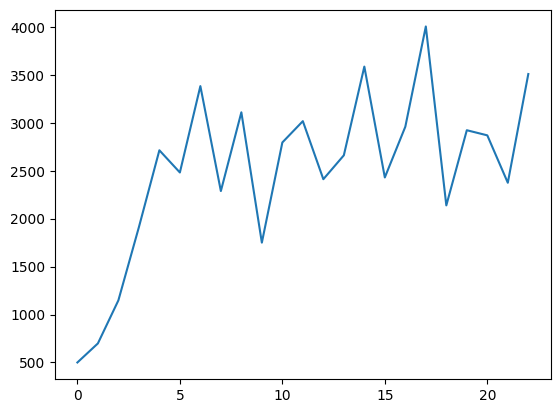

In [100]:
import matplotlib.pyplot as plt 

def american_to_decimal(odds):
    odds = np.asarray(odds)
    return np.where(
        odds > 0, 
        1 + odds / 100, 
        1 + 100 / abs(odds)
    )

def parlay_analysis(df, odds_type=f'open'):

    win_parlay = (
        df[f'choice_fighter_bool_{odds_type}']
        .eq(1)
        .groupby(df['date'])
        .all()
    )

    net_fstar = df.groupby('date')[f'{odds_type}_net_fstar'].first()
    gt_0 = net_fstar > 0 
    fstar = net_fstar.where(gt_0, -1*net_fstar)
    net_odds = df.groupby('date')[f'{odds_type}_net_odds'].first()

    net_pct = fstar * net_odds 
    print(net_pct.sum())

    return net_pct 


def net_ml(df, odds_type, net_pct_parlay):

    df_valid = df.dropna(subset=f'pred_winner_{odds_type}').reset_index(drop=True)

    pred_winner = df_valid[f'pred_winner_{odds_type}'] 
    red_odds= df_valid[f'{odds_type}_red']
    blue_odds= df_valid[f'{odds_type}_blue']

    win_bet = df_valid[f'pred_winner_{odds_type}'] == df_valid[f'winner_bool']

    choice_odds = np.where(pred_winner == 1, american_to_decimal(red_odds)-1, american_to_decimal(blue_odds)-1)
    mask = choice_odds > 0.1
    
    net_odds = np.where(win_bet, choice_odds, -1)[mask]
    
    net_pct = net_odds * df_valid[f'fstar_{odds_type}'].loc[mask]
    print(net_pct.sum())

    net_pct = pd.Series(net_pct)

    history = [500]
    for date, group in net_pct.groupby(df_valid['date']): 
        bankroll = history[-1]
        if bankroll < 500:
            bankroll = 500
        ml_date = group
        profit_ml = (ml_date * bankroll).sum()

        parlay_date = net_pct_parlay[date]
        profit_parlay = parlay_date * bankroll

        print(profit_ml, profit_parlay)
        total_profit = bankroll + profit_ml + profit_parlay
        history.append(total_profit)

    plt.plot(history)


net_pct_parlay = parlay_analysis(df_parlay, 'open')
net_ml(df_ml_history, 'open', net_pct_parlay)
# parlay_analysis(df_parlay, 'open')

# net_ml(df_ml_history, 'close1')
# parlay_analysis(df_parlay, 'close1')

# net_ml(df_ml_history, 'close2')
# parlay_analysis(df_parlay, 'close2')

0.7601158872541656
-0.15260787431375822
53.080737470462005 -67.9339827921728
146.22226575388694 86.12947456789063
254.7122880832558 130.71039832599433
302.0572621256664 215.71064455505132
-274.13204286579406 291.91329129362833
188.8830352971929 295.2964824006938
-668.0680286483448 -226.43657048990292
183.39705335968299 269.24763649343294
-699.4132360501319 -227.59024393795076
-15.245460367998458 -71.29394753323139
-46.68471800993552 -37.507627248601466
-98.64509973356772 122.06904168849911
-93.79566445007305 -117.28394766039784
-13.929013252658201 -41.06775524745515
-89.23637424431385 69.44029406354855
13.124083921790714 -59.223113844968545
157.42059385658314 93.80029463603634
-296.44360655057477 -60.78454972422227
9.236255129747882 73.101404734932
30.90614708401189 -62.891103850055714
-51.57785776221601 -56.54624471360485
73.92387370219765 85.30834752914716


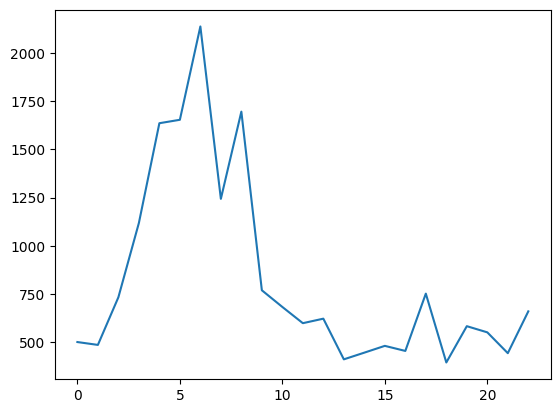

In [101]:
net_pct_parlay = parlay_analysis(df_parlay, 'close1')
net_ml(df_ml_history, 'close1', net_pct_parlay)

In [105]:
df_ml_history.columns

Index(['net_odds_open', 'net_odds_close1', 'net_odds_close2', 'winner_bool',
       'winner_name', 'fighter_red', 'fighter_blue', 'pred_name_open',
       'pred_name_close1', 'pred_name_close2', 'pred_winner_open',
       'pred_winner_close1', 'pred_winner_close2', 'open_red', 'open_blue',
       'close1_red', 'close1_blue', 'close2_red', 'close2_blue', 'fstar_open',
       'fstar_close1', 'fstar_close2', 'date'],
      dtype='str')

In [108]:
np.unique(df_ml_history['date'])

array(['2026-02-28', '2026-03-07', '2026-03-14', '2026-03-21',
       '2026-03-28', '2026-04-04', '2026-04-11', '2026-04-18',
       '2026-04-25', '2026-05-02', '2026-05-09', '2026-05-16',
       '2026-05-30', '2026-06-06', '2026-06-14', '2026-06-20',
       '2026-06-27', '2026-07-11', '2026-07-18', '2026-07-25',
       '2026-08-01', '2026-08-08'], dtype=object)

In [110]:
date7 = np.unique(df_ml_history['date'])[6]
df_ml_history[df_ml_history['date']==date7][['winner_bool','pred_name_close1', 'pred_winner_close1', 'fstar_close1', 'close1_red']]

,winner_bool,pred_name_close1,pred_winner_close1,fstar_close1,close1_red
78,1.0,kevin holland,1.0,0.089653,-142.0
79,1.0,charles radtke,1.0,0.000000,-180.0
80,0.0,kelvin gastelum,1.0,0.000000,-290.0
81,2.0,chris padilla,1.0,0.153510,-175.0
82,1.0,NaN,NaN,NaN,NaN
83,1.0,mateusz gamrot,1.0,0.180848,-260.0
84,0.0,carlos ulberg,1.0,0.033903,-112.0
85,0.0,NaN,NaN,NaN,NaN
86,1.0,cub swanson,1.0,0.064066,-150.0
87,1.0,dominick reyes,1.0,0.015141,-210.0


0.7241953538593572
0.805165923224391
40.96212017802958 86.46931130150989
238.75477328402638 121.22031533861632
346.92808639434963 -77.1342230291894
481.556602978015 285.2759082804309
-231.4811108757437 401.86611918463154
472.8621945776182 433.82016179087435
-950.7478138325048 -306.4982831777421
355.82841239181766 438.8270991854752
-1172.8310658583157 -318.009793406126
113.85922624571393 -81.89176233439079
61.39783289694978 -56.164341948003276
-182.99998413162353 254.72772146221013
-136.82229750021517 -219.04354876415763
20.842525647735272 -66.51940800584562
-96.82837258072631 -174.19256581001736
4.371646953071618 -64.75910263637762
204.17984706517547 103.55554663197461
-323.42050975790943 -63.235328689857226
30.926132600685776 77.5423707061848
48.92322078853095 -60.110288734806254
-30.70839658655499 -55.619315399218515
85.97193684820152 90.06395792922558


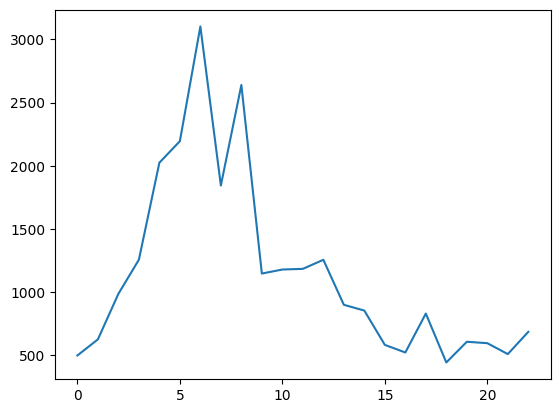

In [98]:
net_pct_parlay = parlay_analysis(df_parlay, 'close2')
net_ml(df_ml_history, 'close2', net_pct_parlay)

In [15]:
ml_results[test_columns].tail(20)

,net_stake_open,net_stake_close1,net_stake_close2,date,fighter_red,fighter_blue,close1_red,close1_blue,close2_red,close2_blue,pred_winner_open,pred_winner_close1,pred_winner_close2,winner_bool
255,0.000000,0.000000,0.000000,2026-08-01,dennis buzukja,bogdan grad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
256,0.145920,0.065244,0.099575,2026-08-01,jan blachowicz,navajo stirling,250.0,-370.0,290.0,-330.0,0.0,0.0,0.0,0.0
257,0.000000,0.000000,0.000000,2026-08-01,oban elliott,michael oliveira,275.0,-910.0,575.0,-350.0,NaN,NaN,NaN,0.0
258,-0.120615,-0.176302,-0.189195,2026-08-01,ludovit klein,tofiq musayev,-275.0,200.0,-250.0,225.0,1.0,1.0,1.0,0.0
259,0.000000,0.000000,0.000000,2026-08-01,milos janicic,noah gugnon,-138.0,-120.0,-105.0,118.0,NaN,NaN,NaN,0.0
260,0.000000,0.000000,0.000000,2026-08-01,vlasto cepo,gilbert urbina,-350.0,230.0,-280.0,275.0,NaN,NaN,NaN,0.0
261,0.152204,0.168451,0.212925,2026-08-01,aleksandar rakic,marcin tybura,-420.0,260.0,-350.0,310.0,1.0,1.0,1.0,1.0
262,-0.085041,-0.000000,-0.000000,2026-08-01,dusko todorovic,robert valentin,125.0,-175.0,140.0,-150.0,1.0,1.0,1.0,0.0
263,0.000000,0.000000,0.000000,2026-08-08,billy ray goff,ty miller,300.0,-500.0,380.0,-400.0,0.0,0.0,0.0,0.0
264,0.080583,0.104996,0.124341,2026-08-08,diego ferreira,billy quarantillo,-188.0,143.0,-175.0,154.0,1.0,1.0,1.0,1.0


In [6]:
test_columns = [
    'date', 'fstar_open', 'fstar_close1', 'fstar_close2',
    'pred_name_close1', 'pred_name_close2', 'pred_name_close1',
    'pred_name_close2',  'winner_bool'
]
df_ml_history[test_columns].tail(20)

,date,fstar_open,fstar_close1,fstar_close2,pred_name_close1,pred_name_close2,pred_name_close1,pred_name_close2,winner_bool
0,2026-08-08,0.051324,0.211296,0.210212,alexia thainara,alexia thainara,alexia thainara,alexia thainara,0.0
1,2026-08-08,0.000000,0.000000,0.000000,quillan salkilld,quillan salkilld,quillan salkilld,quillan salkilld,0.0
2,2026-08-08,0.080583,0.202211,0.201802,diego ferreira,diego ferreira,diego ferreira,diego ferreira,1.0
3,2026-08-08,0.000000,0.000000,0.000000,yadier del valle,yadier del valle,yadier del valle,yadier del valle,0.0
4,2026-08-08,0.062791,0.230644,0.230340,juliana miller,juliana miller,juliana miller,juliana miller,1.0
5,2026-08-08,0.000000,0.000000,0.000000,ty miller,ty miller,ty miller,ty miller,0.0
6,2026-08-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
7,2026-08-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
8,2026-08-08,0.000000,0.200152,0.199538,miles johns,miles johns,miles johns,miles johns,1.0
9,2026-08-08,0.073677,0.187935,0.188803,diyar nurgozhay,diyar nurgozhay,diyar nurgozhay,diyar nurgozhay,1.0


In [23]:
df_ml_history.columns

Index(['net_odds_open', 'net_odds_close1', 'net_odds_close2', 'winner_bool',
       'winner_name', 'fighter_red', 'fighter_blue', 'pred_name_open',
       'pred_name_close1', 'pred_name_close2', 'pred_winner_open',
       'pred_winner_close1', 'pred_winner_close2', 'open_red', 'open_blue',
       'close1_red', 'close1_blue', 'close2_red', 'close2_blue', 'fstar_open',
       'fstar_close1', 'fstar_close2', 'date'],
      dtype='str')

In [ ]:
choice_odds = np.where(
    bets_only[f'pred_winner_{type_}'] == 1, 
    bets_only[f'{type_}_red'], 
    bets_only[f'{type_}_blue']
)

dog_bets = bets_only[choice_odds > 0]
fav_bets = bets_only[choice_odds < 0]
total_dog = dog_bets.shape[0]

print(choice_odds.shape)